# pinn_dispersion_from_mat.ipynb — PINN Dispersion from Saved Results

**Approach 2 of 2 — Finite Lattice (PINN-based), Stage 2 only**

> **No PINN retraining required.**  
> This notebook loads pre-computed results from `PINN_ndofs_nmasses/pinn_ndof_chain_sim.ipynb`
> saved as a `.mat` file, then performs the spectral analysis.

## Workflow

```
Stage 1  (pinn_ndof_chain_sim.ipynb)
   Run PINN segments → stitch x_n(t) → save_pinn_results('pinn_results.mat', ...)

Stage 2  (this notebook)
   load_pinn_results('pinn_results.mat')
   → resample to uniform dt
   → 2-D FFT  →  S(k, ω)
   → heatmap  +  DOS  +  per-band ridges
```

## Why this is the "real" dispersion

| | Bloch (Approach 1) | PINN finite lattice (this notebook) |
|---|---|---|
| Lattice size | Infinite | Finite (N unit cells as simulated) |
| Boundary conditions | Periodic (exact) | Actual BCs of the simulation |
| Impact timing | Determined by single-cell orbit | Exact root-finding per segment |
| Spatial non-uniformity | Assumed identical cells | Each cell evolves freely |
| Multi-band | Fundamental branch only | Full harmonic structure visible |

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks

from pinn_dispersion_from_mat import (
    load_pinn_results,
    resample_to_uniform,
    compute_spectrum,
    clip_spectrum,
    compute_dos,
    detect_band_gaps,
    extract_ridge_in_band,
    linear_dispersion,
    plot_dispersion_heatmap,
)

mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'pdf.fonttype': 42,
})
FS = 20
LW = 2.0
print('Modules loaded.')

Modules loaded.


## Load .mat file

Set `mat_path` to the file saved by `pinn_ndof_chain_sim.ipynb`.

In [2]:
mat_path = 'pinn_results.mat'   # ← adjust if needed

t_total, x_PINN_total, params = load_pinn_results(mat_path)

# ── Extract parameters ─────────────────────────────────────────────────────
n_dof = int(params.get('n_dof', x_PINN_total.shape[1]))
mx    = float(params.get('mx', 1.0))
my    = float(params.get('my', 0.3))
K     = float(params.get('k',  1.0))
D     = float(params.get('D',  1.0))
r     = float(params.get('r',  1))

omega_max_lin = 2.0 * np.sqrt(K / mx)

print(f'\nParameters from .mat:')
print(f'  n_dof={n_dof}, mx={mx}, my={my}, K={K}, D={D}, r={r}')
print(f'  ω_max_lin = {omega_max_lin:.4f} rad/s')

Loaded  pinn_results.mat
  t_total      : (50050,),  span 0.000 – 13.740 s
  x_PINN_total : (50050, 20)
  params       : ['n_dof', 'mx', 'my', 'k', 'c', 'D', 'r', 'phi1', 'phi2']

Parameters from .mat:
  n_dof=20, mx=1.0, my=0.3, K=1.0, D=1.0, r=1.0
  ω_max_lin = 2.0000 rad/s


## Resample to uniform time grid

PINN segments have variable lengths → the stitched `t_total` is piecewise-uniform.
The 2-D FFT requires a globally uniform grid.

In [3]:
# x_PINN_total is (N_time, n_dof); transpose to (n_dof, N_time) for FFT
X_raw = x_PINN_total.T

n_harmonic    = 4      # resolve up to 4th harmonic band
pts_per_cycle = 10     # samples per shortest cycle

t_uniform, X_uniform, dt, omega_nyquist = resample_to_uniform(
    t_total, X_raw, omega_max_lin,
    n_harmonic=n_harmonic,
    pts_per_cycle=pts_per_cycle,
)

print(f'Uniform grid : {X_uniform.shape}  (n_dof × N_time)')
print(f'dt           : {dt:.5f} s')
print(f'ω_nyquist    : {omega_nyquist:.3f} rad/s')
print(f'ω resolution : {2*np.pi/(t_uniform[-1]-t_uniform[0]):.4f} rad/s')

Uniform grid : (20, 175)  (n_dof × N_time)
dt           : 0.07854 s
ω_nyquist    : 40.000 rad/s
ω resolution : 0.4598 rad/s


## 2-D FFT → dispersion spectrum S(k, ω)

In [4]:
k_pos, omega_pos, spectrum = compute_spectrum(t_uniform, X_uniform, skip_transient=0.15)

print(f'k range  : {k_pos[0]:.3f} → {k_pos[-1]:.3f} rad/unit-cell')
print(f'ω range  : {omega_pos[0]:.3f} → {omega_pos[-1]:.3f} rad/s')
print(f'Spectrum : {spectrum.shape}')

k range  : 0.000 → 3.142 rad/unit-cell
ω range  : 0.000 → 39.732 rad/s
Spectrum : (11, 75)


In [5]:

# ── Estimate effective internal spring from the observed DOS flat band ─────────
#
# Theory (mass-in-mass chain):
#   The impact dampers act like an effective internal spring k_int_eff.
#   The resonance frequency of that spring is:
#       ω_res = √(k_int_eff / my)    →    k_int_eff = my · ω_res²
#
# We estimate ω_res from the first pronounced peak in the DOS (pass band centre).
# Then the analytical mass-in-mass band-gap edges are:
#   ω_gap_lo = √(k_int_eff / my)
#   ω_gap_hi = √(k_int_eff · (mx + my) / (mx · my))
# ──────────────────────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from dispersion_theory import (
    estimate_k_int,
    band_gap_edges,
    mass_in_mass_dispersion,
    monoatomic_dispersion as _mono_disp,
)

# Quick DOS on full spectrum to find the lowest pass-band frequency
_dos, _dos_dB = compute_dos(spectrum)
_band_peaks, _ = detect_band_gaps(omega_pos, _dos_dB, dip_threshold_dB=3.0, min_distance=3)

# Use the first band-peak (lowest pass-band centre) as the resonance estimate
if len(_band_peaks) > 0:
    omega_flat_est = float(_band_peaks[0])
else:
    omega_flat_est = omega_max_lin / 2.0   # fallback

k_int_eff       = estimate_k_int(omega_flat_est, my)
omega_gap_lo, omega_gap_hi = band_gap_edges(K, mx, my, k_int_eff)

print(f'Lowest DOS pass-band centre : {omega_flat_est:.4f} rad/s')
print(f'Estimated  k_int_eff        : {k_int_eff:.4f}')
print(f'Analytical band-gap edges   : [{omega_gap_lo:.3f}, {omega_gap_hi:.3f}] rad/s'
      f'  (width = {omega_gap_hi - omega_gap_lo:.3f})')


Lowest DOS pass-band centre : 5.3691 rad/s
Estimated  k_int_eff        : 8.6483
Analytical band-gap edges   : [5.369, 6.122] rad/s  (width = 0.753)


## Full-band dispersion heatmap

- White dashed — linear acoustic branch  
- Cyan dotted  — effective impact resonance $\omega_\mathrm{eff}$ and harmonics

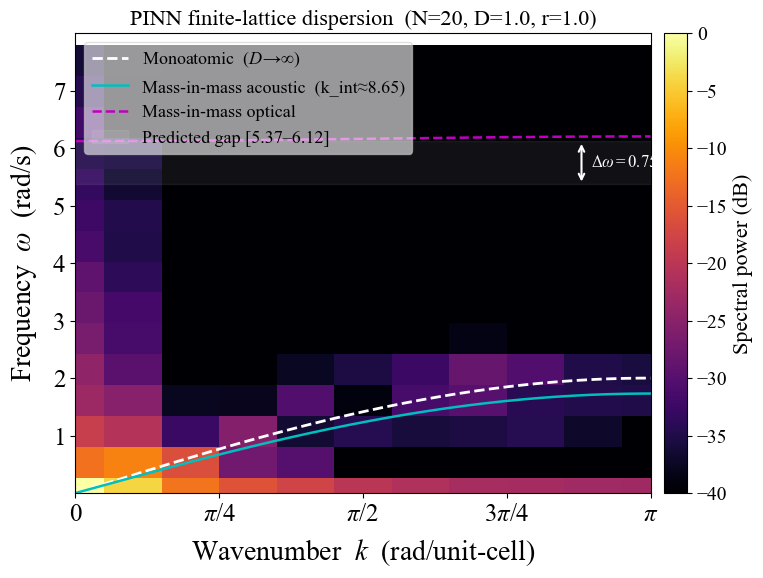

In [6]:
omega_eff     = omega_max_lin / 3.0   # rough initial estimate
n_bands_shown = 4
omega_max_plot = n_bands_shown * max(omega_eff, omega_max_lin)

k_c, omega_c, spec_c = clip_spectrum(k_pos, omega_pos, spectrum, omega_max_plot)

S_dB = 10.0 * np.log10(spec_c + 1e-30)
S_dB -= S_dB.max()
S_dB  = np.clip(S_dB, -40.0, 0.0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(k_c, omega_c, S_dB.T,
                   cmap='inferno', shading='auto', vmin=-40.0, vmax=0.0)
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Spectral power (dB)', fontsize=FS - 4)
cbar.ax.tick_params(labelsize=FS - 6)

k_line = np.linspace(1e-4, np.pi, 300)

# Linear (monoatomic) branch
ax.plot(k_line,
        linear_dispersion(k_line, K, mx),
        'w--', lw=LW, label=r'Monoatomic  ($D\!\to\!\infty$)')

# ── Mass-in-mass analytical overlay ──────────────────────────────────────────
om_lo_mim, om_hi_mim = mass_in_mass_dispersion(k_line, K, mx, my, k_int_eff)
ax.plot(k_line, om_lo_mim, 'c-',  lw=LW * 0.9,
        label=f'Mass-in-mass acoustic  (k_int≈{k_int_eff:.2f})')
ax.plot(k_line, om_hi_mim, 'm--', lw=LW * 0.9,
        label=f'Mass-in-mass optical')

# Shade predicted band gap
ax.axhspan(omega_gap_lo, omega_gap_hi,
           color='white', alpha=0.07,
           label=f'Predicted gap [{omega_gap_lo:.2f}–{omega_gap_hi:.2f}]')

# Annotate gap width with a double-arrow
x_ann = np.pi * 0.88
ax.annotate('', xy=(x_ann, omega_gap_hi), xytext=(x_ann, omega_gap_lo),
            arrowprops=dict(arrowstyle='<->', color='white', lw=1.5))
ax.text(x_ann + 0.05, (omega_gap_lo + omega_gap_hi) / 2,
        fr'$\Delta\omega={omega_gap_hi - omega_gap_lo:.2f}$',
        color='white', fontsize=FS - 8, va='center')
# ─────────────────────────────────────────────────────────────────────────────

ax.set_xlabel(r'Wavenumber  $k$  (rad/unit-cell)', fontsize=FS, labelpad=8)
ax.set_ylabel(r'Frequency  $\omega$  (rad/s)',      fontsize=FS, labelpad=10)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, omega_max_plot)
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.yaxis.set_major_locator(MaxNLocator(nbins=8, prune='both'))
ax.tick_params(axis='both', labelsize=FS - 2)
ax.legend(fontsize=FS - 7, loc='upper left', framealpha=0.6)
ax.set_title(f'PINN finite-lattice dispersion  (N={n_dof}, D={D}, r={r})',
             fontsize=FS - 4)
plt.tight_layout(pad=1.5)
plt.savefig('pinn_mat_dispersion_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## Density of States (DOS) — automatic band-gap detection

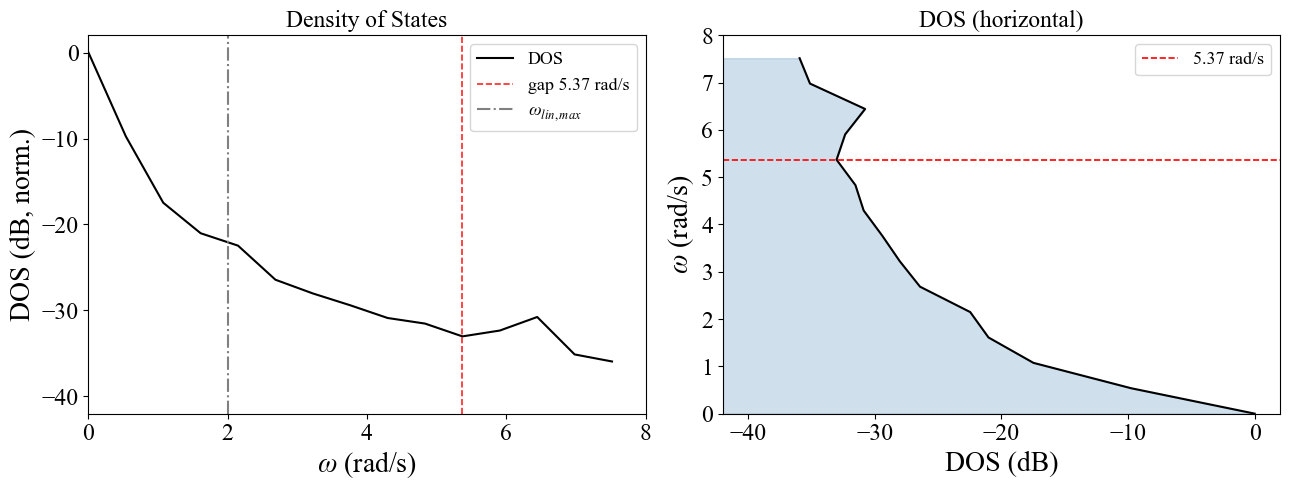

Pass-band centres (rad/s): []
Band-gap centres  (rad/s): [5.369]


In [7]:
dos, dos_dB = compute_dos(spec_c)
gap_freqs, band_freqs = detect_band_gaps(omega_c, dos_dB,
                                         dip_threshold_dB=5.0, min_distance=5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(omega_c, dos_dB, 'k-', lw=1.5, label='DOS')
for gf in gap_freqs:
    ax.axvline(gf, color='red', lw=1.2, ls='--', alpha=0.85,
               label=f'gap {gf:.2f} rad/s')
ax.axvline(omega_max_lin, color='gray', lw=1.5, ls='-.',
           label=r'$\omega_{lin,max}$')
ax.set_xlabel(r'$\omega$ (rad/s)', fontsize=FS)
ax.set_ylabel('DOS (dB, norm.)',   fontsize=FS)
ax.set_xlim(0, omega_max_plot)
ax.set_ylim(-42, 2)
ax.tick_params(labelsize=FS - 3)
ax.legend(fontsize=FS - 7)
ax.set_title('Density of States', fontsize=FS - 3)

ax2 = axes[1]
ax2.plot(dos_dB, omega_c, 'k-', lw=1.5)
ax2.fill_betweenx(omega_c, dos_dB, -42, alpha=0.25, color='steelblue')
for gf in gap_freqs:
    ax2.axhline(gf, color='red', lw=1.2, ls='--', label=f'{gf:.2f} rad/s')
ax2.set_ylabel(r'$\omega$ (rad/s)', fontsize=FS)
ax2.set_xlabel('DOS (dB)',          fontsize=FS)
ax2.set_ylim(0, omega_max_plot)
ax2.set_xlim(-42, 2)
ax2.tick_params(labelsize=FS - 3)
if len(gap_freqs):
    ax2.legend(fontsize=FS - 7)
ax2.set_title('DOS (horizontal)', fontsize=FS - 3)

plt.tight_layout()
plt.savefig('pinn_mat_dos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pass-band centres (rad/s): {np.round(band_freqs, 3)}')
print(f'Band-gap centres  (rad/s): {np.round(gap_freqs,  3)}')

## Multi-band ridge extraction

Per-band dominant ω(k) curves, separated by the auto-detected gap frequencies.

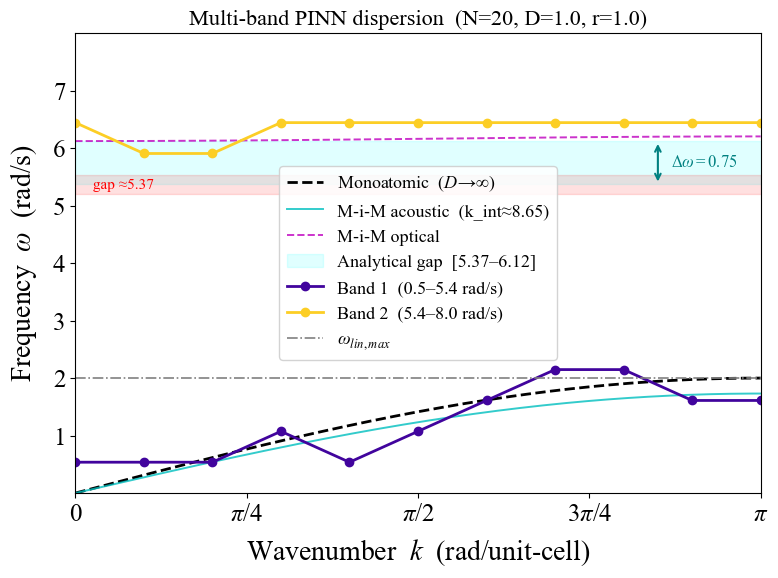


  Band        ω window (rad/s)    k pts with ridge
     1        0.50 – 5.37                        11
     2        5.37 – 8.00                        11

Analytical gap : [5.369, 6.122] rad/s  (width = 0.753)
k_int_eff      : 8.6483  (estimated from DOS peak at 5.369 rad/s)


In [8]:
band_edges = np.concatenate([[0.5], np.sort(gap_freqs), [omega_max_plot]])
palette    = plt.cm.plasma(np.linspace(0.1, 0.9, max(len(band_edges) - 1, 1)))

fig, ax = plt.subplots(figsize=(8, 6))

k_line = np.linspace(1e-4, np.pi, 300)
ax.plot(k_line,
        linear_dispersion(k_line, K, mx),
        'k--', lw=LW, label=r'Monoatomic  ($D\!\to\!\infty$)')

# Mass-in-mass analytical branches (overlay)
om_lo_mim, om_hi_mim = mass_in_mass_dispersion(k_line, K, mx, my, k_int_eff)
ax.plot(k_line, om_lo_mim, 'c-',  lw=1.4, alpha=0.8,
        label=f'M-i-M acoustic  (k_int≈{k_int_eff:.2f})')
ax.plot(k_line, om_hi_mim, 'm--', lw=1.4, alpha=0.8,
        label='M-i-M optical')

# Analytical band-gap shading + annotation
ax.axhspan(omega_gap_lo, omega_gap_hi, color='cyan', alpha=0.12,
           label=f'Analytical gap  [{omega_gap_lo:.2f}–{omega_gap_hi:.2f}]')
x_gap_ann = np.pi * 0.85
ax.annotate('', xy=(x_gap_ann, omega_gap_hi), xytext=(x_gap_ann, omega_gap_lo),
            arrowprops=dict(arrowstyle='<->', color='teal', lw=1.5))
ax.text(x_gap_ann + 0.06, (omega_gap_lo + omega_gap_hi) / 2,
        fr'$\Delta\omega={omega_gap_hi - omega_gap_lo:.2f}$',
        color='teal', fontsize=FS - 8, va='center')

for b, (lo, hi) in enumerate(zip(band_edges[:-1], band_edges[1:])):
    i_lo = np.searchsorted(omega_c, lo)
    i_hi = np.searchsorted(omega_c, hi)
    if i_hi <= i_lo:
        continue
    omega_ridge = extract_ridge_in_band(
        k_c, omega_c[i_lo:i_hi], spec_c[:, i_lo:i_hi], omega_min=lo)
    valid = ~np.isnan(omega_ridge)
    if valid.any():
        ax.plot(k_c[valid], omega_ridge[valid],
                'o-', color=palette[b], lw=LW, ms=6,
                label=f'Band {b+1}  ({lo:.1f}–{hi:.1f} rad/s)')

# PINN gap centres (detected from DOS)
for gf in gap_freqs:
    ax.axhspan(gf * 0.97, gf * 1.03, color='red', alpha=0.12)
    ax.text(np.pi * 0.02, gf, f' gap ≈{gf:.2f}', color='red',
            fontsize=FS - 9, va='center')

ax.axhline(omega_max_lin, color='gray', lw=1.2, ls='-.',
           label=r'$\omega_{lin,max}$')

ax.set_xlabel(r'Wavenumber  $k$  (rad/unit-cell)', fontsize=FS, labelpad=8)
ax.set_ylabel(r'Frequency  $\omega$  (rad/s)',      fontsize=FS, labelpad=10)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, omega_max_plot)
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.yaxis.set_major_locator(MaxNLocator(nbins=8, prune='both'))
ax.tick_params(axis='both', labelsize=FS - 2)
ax.legend(fontsize=FS - 7, loc='best', framealpha=0.85)
ax.set_title(f'Multi-band PINN dispersion  (N={n_dof}, D={D}, r={r})',
             fontsize=FS - 4)
plt.tight_layout(pad=1.5)
plt.savefig('pinn_mat_multiband.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'Band':>6}  {'ω window (rad/s)':>22}  {'k pts with ridge':>18}")
for b, (lo, hi) in enumerate(zip(band_edges[:-1], band_edges[1:])):
    i_lo = np.searchsorted(omega_c, lo)
    i_hi = np.searchsorted(omega_c, hi)
    ridge = extract_ridge_in_band(k_c, omega_c[i_lo:i_hi], spec_c[:, i_lo:i_hi])
    nv    = int((~np.isnan(ridge)).sum())
    print(f"{b+1:>6}  {lo:>10.2f} – {hi:<10.2f}  {nv:>18}")

print(f'\nAnalytical gap : [{omega_gap_lo:.3f}, {omega_gap_hi:.3f}] rad/s  '
      f'(width = {omega_gap_hi - omega_gap_lo:.3f})')
print(f'k_int_eff      : {k_int_eff:.4f}  (estimated from DOS peak at {omega_flat_est:.3f} rad/s)')


## Multi-band effect — annotated composite figure

**What is the multi-band effect?**

A **linear** spring chain has exactly **one** dispersion branch:
$$\omega(k) = 2\sqrt{K/M}\,\left|\sin\!\frac{k}{2}\right|$$
Every spatial frequency k carries energy at a unique temporal frequency ω.

Adding **nonlinear impact dampers** breaks this single-branch picture through two mechanisms:

| Mechanism | Result |
|---|---|
| Impact creates a *local resonance* | Energy concentrates near a fixed ω independent of k → **flat band** |
| Nonlinearity generates harmonics | Energy also appears at 2ω, 3ω, … → **multiple flat bands** |
| Acoustic + impact hybridise | Frequency ranges with zero DOS → **band gaps** |

The figure below shows all three effects simultaneously:
- **Left** — 2-D power spectrum S(k,ω): bright = high energy  
- **Centre** — Density of States (DOS = spectrum integrated over all k): peaks = pass bands, valleys = band gaps  
- **Right** — Band-by-band ridge curves ω(k): each coloured line is one band

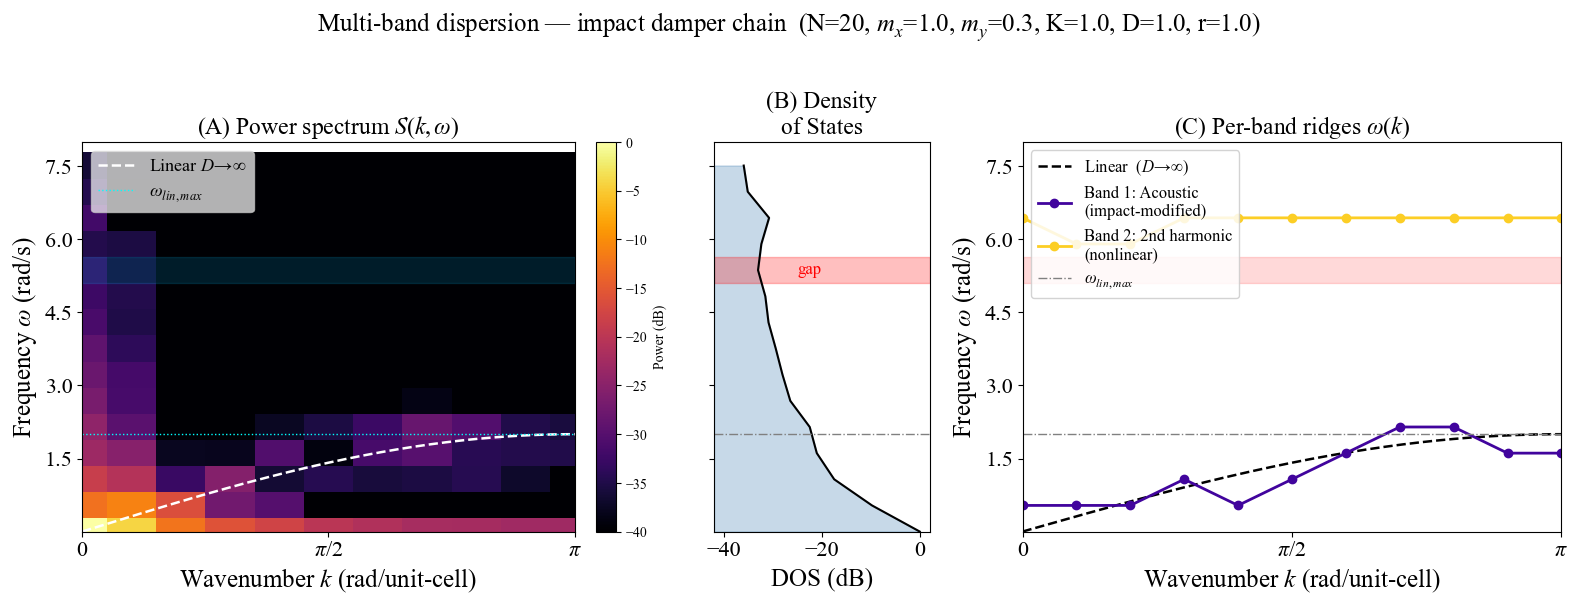


ω_max_lin = 2.000 rad/s  (top of bare-chain acoustic branch)

 Band         ω range (rad/s)   Flat?  Physical interpretation
---------------------------------------------------------------------------
    1       0.50 – 5.37           no   Acoustic
(impact-modified)
    2       5.37 – 8.00           yes  2nd harmonic
(nonlinear)


In [9]:
# ── Three-panel multi-band figure ─────────────────────────────────────────
#
#  Panel A (left)   : 2-D spectrum heatmap — shows WHERE energy is in (k, ω)
#  Panel B (centre) : Density of States (DOS) — shows WHICH ω have energy
#  Panel C (right)  : Per-band ridge ω(k)    — shows the dispersion of each band
#
#  Reading guide:
#   • Bright horizontal stripes in A → flat bands (k-independent impact resonances)
#   • Dark horizontal stripes in A → band gaps (no propagation)
#   • Peaks in DOS (B) mark pass bands; valleys mark band gaps
#   • Flat coloured lines in C confirm the bands are nearly non-dispersive
#   • Dashed black = linear acoustic branch (would be the only branch without impacts)
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [2.5, 1, 2.5]})

# ── shared ω range ────────────────────────────────────────────────────────
om_max = omega_max_plot
k_line = np.linspace(0, np.pi, 300)
om_lin = linear_dispersion(k_line, K, mx)

# ── Panel A: 2-D spectrum heatmap ─────────────────────────────────────────
ax_A = axes[0]

S_dB_A = 10.0 * np.log10(spec_c + 1e-30)
S_dB_A -= S_dB_A.max()
S_dB_A  = np.clip(S_dB_A, -40.0, 0.0)

im = ax_A.pcolormesh(k_c, omega_c, S_dB_A.T,
                     cmap='inferno', shading='auto',
                     vmin=-40.0, vmax=0.0)
fig.colorbar(im, ax=ax_A, label='Power (dB)', fraction=0.046, pad=0.04)

ax_A.plot(k_line, om_lin, 'w--', lw=1.8, label=r'Linear $D\!\to\!\infty$')
ax_A.axhline(omega_max_lin, color='cyan', lw=1.0, ls=':',
             label=r'$\omega_{lin,max}$')

# Annotate band-gap regions
for gf in gap_freqs:
    ax_A.axhspan(gf * 0.95, gf * 1.05, color='deepskyblue', alpha=0.15)

ax_A.set_xlabel(r'Wavenumber $k$ (rad/unit-cell)', fontsize=FS - 2)
ax_A.set_ylabel(r'Frequency $\omega$ (rad/s)',      fontsize=FS - 2)
ax_A.set_xlim(0, np.pi)
ax_A.set_ylim(0, om_max)
ax_A.set_xticks([0, np.pi/2, np.pi])
ax_A.set_xticklabels(['0', r'$\pi/2$', r'$\pi$'], fontsize=FS - 4)
ax_A.yaxis.set_major_locator(MaxNLocator(nbins=7, prune='both'))
ax_A.tick_params(labelsize=FS - 4)
ax_A.legend(fontsize=FS - 7, loc='upper left', framealpha=0.7)
ax_A.set_title('(A) Power spectrum $S(k,\omega)$', fontsize=FS - 3)

# ── Panel B: DOS ──────────────────────────────────────────────────────────
ax_B = axes[1]

dos_B, dos_dB_B = compute_dos(spec_c)
ax_B.plot(dos_dB_B, omega_c, 'k-', lw=1.5)
ax_B.fill_betweenx(omega_c, dos_dB_B, -42, alpha=0.3, color='steelblue',
                   label='Pass band')

# Mark gap centres and band centres
gap_freqs_B, band_freqs_B = detect_band_gaps(omega_c, dos_dB_B,
                                              dip_threshold_dB=5.0, min_distance=5)
for gf in gap_freqs_B:
    ax_B.axhspan(gf * 0.95, gf * 1.05, color='red', alpha=0.25)
    ax_B.annotate('gap', xy=(-25, gf), fontsize=FS - 8, color='red',
                  va='center', ha='left')
for bf in band_freqs_B:
    ax_B.annotate('pass\nband', xy=(-10, bf), fontsize=FS - 9, color='navy',
                  va='center', ha='right')

ax_B.axhline(omega_max_lin, color='gray', lw=1.0, ls='-.',
             label=r'$\omega_{lin,max}$')
ax_B.set_xlabel('DOS (dB)', fontsize=FS - 2)
ax_B.set_ylabel('')
ax_B.set_ylim(0, om_max)
ax_B.set_xlim(-42, 2)
ax_B.yaxis.set_major_locator(MaxNLocator(nbins=7, prune='both'))
ax_B.set_yticklabels([])
ax_B.tick_params(labelsize=FS - 4)
ax_B.set_title('(B) Density\nof States', fontsize=FS - 3)

# ── Panel C: per-band ridge curves ────────────────────────────────────────
ax_C = axes[2]

ax_C.plot(k_line, om_lin, 'k--', lw=1.8,
          label=r'Linear  ($D\!\to\!\infty$)')

band_labels = {
    0: 'Acoustic\n(impact-modified)',
    1: '2nd harmonic\n(nonlinear)',
    2: '3rd harmonic',
    3: '4th harmonic',
}

for b, (lo, hi) in enumerate(zip(band_edges[:-1], band_edges[1:])):
    i_lo = np.searchsorted(omega_c, lo)
    i_hi = np.searchsorted(omega_c, hi)
    if i_hi <= i_lo:
        continue
    ridge = extract_ridge_in_band(
        k_c, omega_c[i_lo:i_hi], spec_c[:, i_lo:i_hi], omega_min=lo)
    valid = ~np.isnan(ridge)
    if not valid.any():
        continue
    lbl = band_labels.get(b, f'Band {b+1}')
    ax_C.plot(k_c[valid], ridge[valid],
              'o-', color=palette[b], lw=2.0, ms=6,
              label=f'Band {b+1}: {lbl}')

# Band-gap shading
for gf in gap_freqs:
    ax_C.axhspan(gf * 0.95, gf * 1.05, color='red', alpha=0.15)

ax_C.axhline(omega_max_lin, color='gray', lw=1.0, ls='-.',
             label=r'$\omega_{lin,max}$')

ax_C.set_xlabel(r'Wavenumber $k$ (rad/unit-cell)', fontsize=FS - 2)
ax_C.set_ylabel(r'Frequency $\omega$ (rad/s)',      fontsize=FS - 2)
ax_C.set_xlim(0, np.pi)
ax_C.set_ylim(0, om_max)
ax_C.set_xticks([0, np.pi/2, np.pi])
ax_C.set_xticklabels(['0', r'$\pi/2$', r'$\pi$'], fontsize=FS - 4)
ax_C.yaxis.set_major_locator(MaxNLocator(nbins=7, prune='both'))
ax_C.tick_params(labelsize=FS - 4)
ax_C.legend(fontsize=FS - 8, loc='upper left', framealpha=0.85)
ax_C.set_title('(C) Per-band ridges $\omega(k)$', fontsize=FS - 3)

fig.suptitle(
    f'Multi-band dispersion — impact damper chain  '
    f'(N={n_dof}, $m_x$={mx}, $m_y$={my}, K={K}, D={D}, r={r})',
    fontsize=FS - 2, y=1.01,
)
plt.tight_layout(pad=1.5)
plt.savefig('pinn_mat_multiband_annotated.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\nω_max_lin = {omega_max_lin:.3f} rad/s  (top of bare-chain acoustic branch)")
print(f"\n{'Band':>5}  {'ω range (rad/s)':>22}  {'Flat?':>6}  Physical interpretation")
print('-' * 75)
for b, (lo, hi) in enumerate(zip(band_edges[:-1], band_edges[1:])):
    i_lo = np.searchsorted(omega_c, lo)
    i_hi = np.searchsorted(omega_c, hi)
    ridge = extract_ridge_in_band(k_c, omega_c[i_lo:i_hi], spec_c[:, i_lo:i_hi])
    valid = ridge[~np.isnan(ridge)]
    if len(valid) < 2:
        continue
    flatness = np.std(valid) / (np.mean(valid) + 1e-12)
    flat_str = 'yes' if flatness < 0.05 else 'no '
    interp = band_labels.get(b, 'higher harmonic')
    print(f"{b+1:>5}  {lo:>9.2f} – {hi:<10.2f}  {flat_str:>6}  {interp}")